# Decision Trees

**Learning Objectives:**
- Train and visualize a Decision Tree classifier
- Understand splitting criteria (Gini impurity)
- Tune max_depth and min_samples_split to prevent overfitting
- Interpret feature importances

**Dataset:** Pima Indians Diabetes

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn import tree
import numpy as np

seed = 42

Decision Trees split data recursively by feature thresholds. No scaling needed.

In [4]:
df = pd.read_csv('data/diabetes.csv')

train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['Outcome'], axis=1)
y_train = train_set['Outcome']
X_test = test_set.drop(['Outcome'], axis=1)
y_test = test_set['Outcome']

### Default Tree (Unconstrained)

Grows until pure leaves — likely overfits.

In [5]:
clf_tree = tree.DecisionTreeClassifier(random_state=seed).fit(X_train, y_train)
y_preds = clf_tree.predict(X_test)
print(f'Accuracy (default tree): {accuracy_score(y_test, y_preds):.4f}')

Accuracy (default tree): 0.6930


### Visualize the Tree

Need graphviz installed (`pip install graphviz`).

In [6]:
try:
    import graphviz
    tree_image = tree.export_graphviz(clf_tree, filled=True, rounded=True, feature_names=X_train.columns)
    graph = graphviz.Source(tree_image)
    graph
except ImportError:
    print('Install graphviz: pip install graphviz')

Install graphviz: pip install graphviz


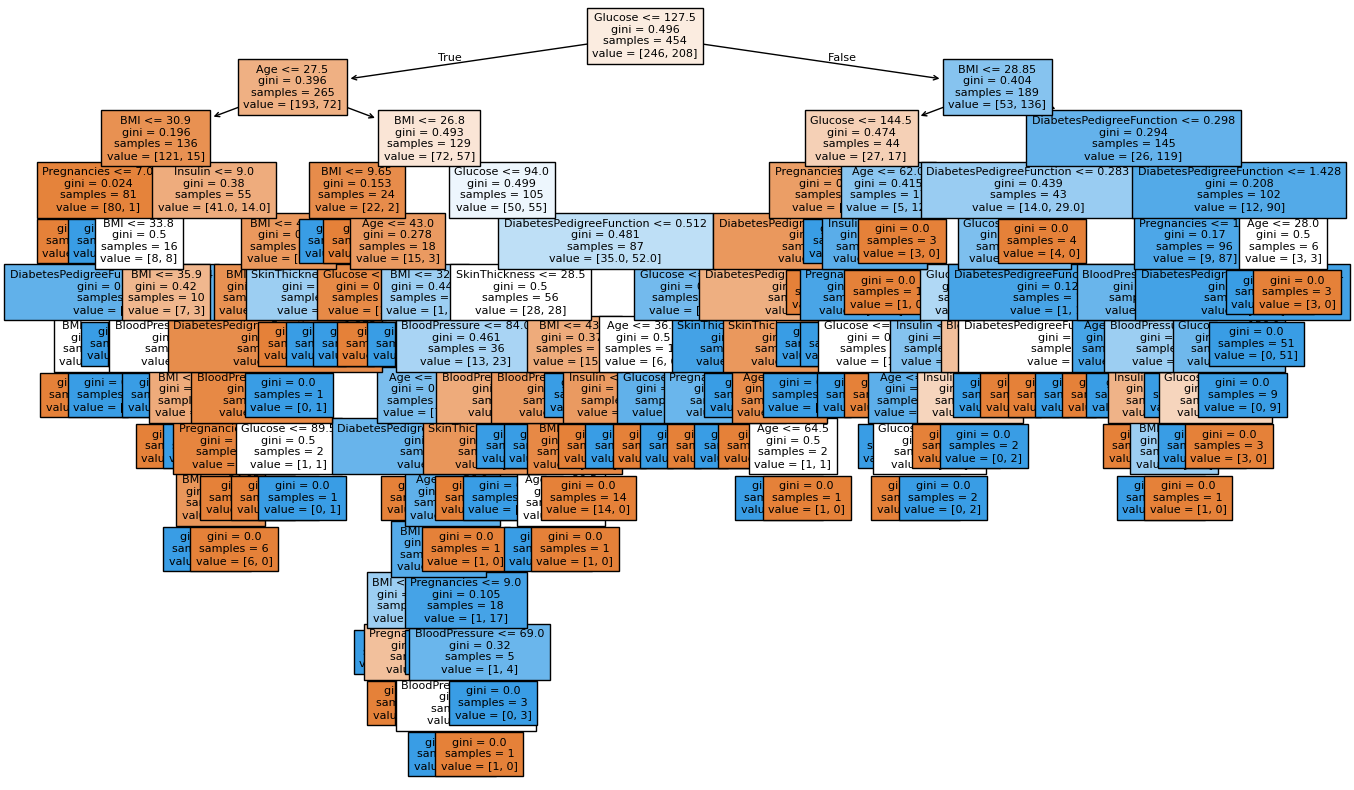

In [7]:
plt.figure(figsize=(16, 10))
tree.plot_tree(clf_tree, fontsize=8, filled=True, feature_names=X_train.columns)
plt.show()

### Feature Importances

How much each feature contributes to reducing impurity across all splits.

In [8]:
importances = pd.DataFrame({'feature': X_train.columns, 'importance': clf_tree.feature_importances_})
importances.sort_values('importance', ascending=False)

,feature,importance
1,Glucose,0.327251
5,BMI,0.207523
7,Age,0.158109
6,DiabetesPedigreeFunction,0.095367
2,BloodPressure,0.084561
4,Insulin,0.050261
3,SkinThickness,0.038963
0,Pregnancies,0.037966


Text(0.5, 1.0, 'Feature Importances')

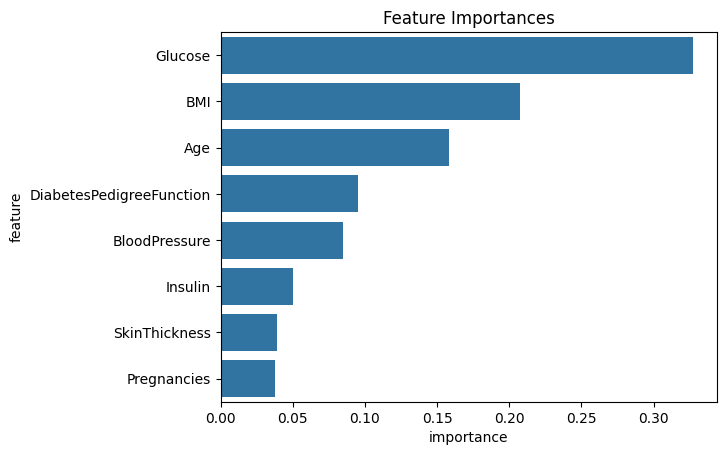

In [9]:
importances.sort_values('importance', ascending=False, inplace=True)
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Feature Importances')

### GridSearchCV — Prune the Tree

`max_depth`: limits tree depth. `min_samples_split`: minimum samples to split a node. Both prevent overfitting.

In [10]:
clf_tree = tree.DecisionTreeClassifier(random_state=seed)
parameters = {'max_depth': [3, 6, 10], 'min_samples_split': [2, 4, 10]}

clf = GridSearchCV(clf_tree, parameters, cv=5).fit(X_train, y_train)

In [11]:
print(f'Best params: {clf.best_params_}')
print(f'Best CV score: {clf.best_score_:.4f}')

Best params: {'max_depth': 6, 'min_samples_split': 2}
Best CV score: 0.6983


In [12]:
y_preds = clf.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, y_preds):.4f}')

Test accuracy: 0.6930


### Visualize the Pruned Tree

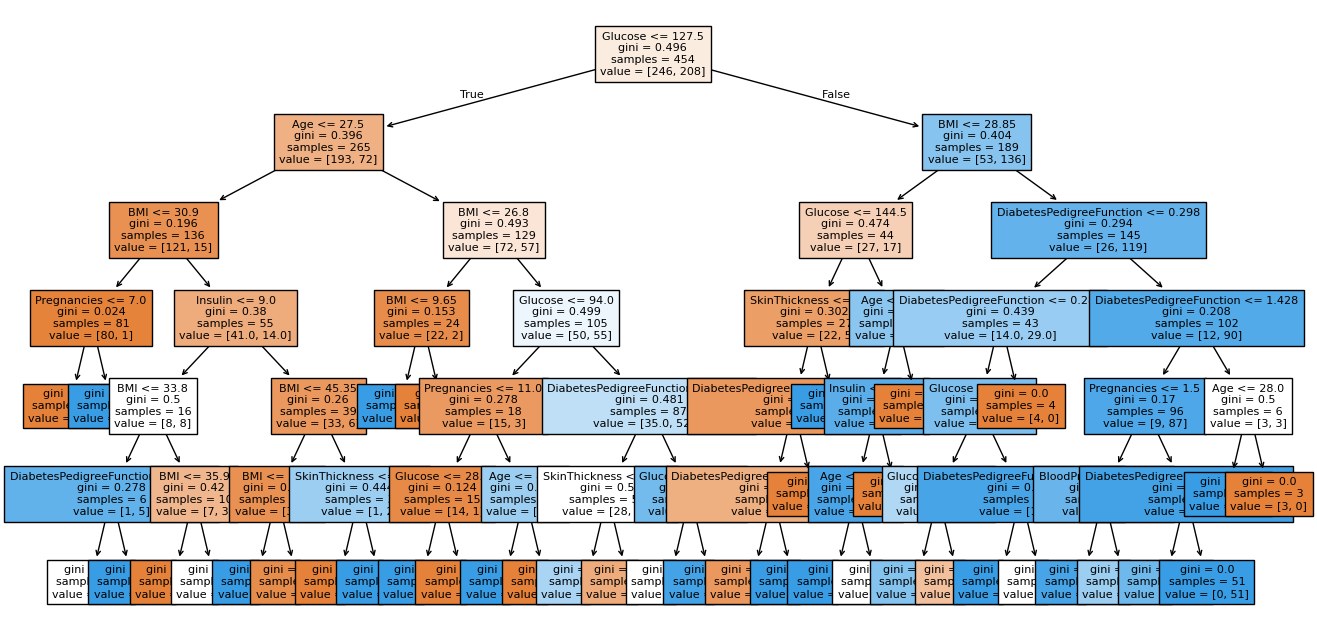

In [13]:
clf_pruned = tree.DecisionTreeClassifier(**clf.best_params_, random_state=seed).fit(X_train, y_train)

plt.figure(figsize=(16, 8))
tree.plot_tree(clf_pruned, fontsize=8, filled=True, feature_names=X_train.columns)
plt.show()

Pruned tree is simpler and generalizes better than the unconstrained one.

### Parameter Notes — DecisionTreeClassifier

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `criterion` | 'gini' | Split quality: 'gini' (Gini impurity), 'entropy' (information gain). | 'gini', 'entropy' |
| `max_depth` | None | Max tree depth. None = grow until pure. Lower → less overfitting. | 3–20, None |
| `min_samples_split` | 2 | Min samples to split a node. Higher → simpler trees. | 2–50 |
| `min_samples_leaf` | 1 | Min samples per leaf. Higher → smoother boundaries. | 1–20 |
| `max_features` | None | Features per split. 'sqrt', 'log2', None (all). | None, 'sqrt', 'log2' |
| `ccp_alpha` | 0.0 | Cost-complexity pruning. Higher → more aggressive pruning. | 0.0–0.05 |

**Key trade-offs:**
- `max_depth` ↓ + `min_samples_split` ↑ → simpler tree, less overfitting
- No scaling needed — trees are invariant to feature scales

## Exercise — Banknote Authentication

Apply Decision Tree to the Banknote dataset.
Source: https://archive.ics.uci.edu/ml/datasets/banknote+authentication

In [14]:
df_bn = pd.read_csv('data/banknote_data.csv')
df_bn.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [15]:
df_bn.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [16]:
# TODO: split, train DT, visualize tree, report accuracy and feature importances